# 2026-27 Premier League priors

Builds `manual_priors_2026_27.py` — the `att_str`/`def_str` priors for next
season's non_penalty_bayes model — by blending three sources:

1. **Last season's posterior** (`model_traces/v1/summary_Premier_League_2025-2026.csv`)
   for the 17 teams staying up.
2. **This season's Transfermarkt squad value**, regressed against non-penalty
   PL goals-for/against rate (same ~33%-of-prior role as `value/salary_analysis.ipynb`),
   for all 20 teams.
3. **Promoted-team PL forecast** from `promotion/champ_analysis.ipynb`'s promotion-effect
   model, for Hull, Coventry and Ipswich.

Everything gets converted into the model's own log-strength units so it drops
straight into `att_mu`/`def_mu` in `src/model.py`, blended 67% (source 1 or 3) /
33% (source 2), then re-centered to zero mean (identifiability constraint).

Relegated (real, penalty-inclusive table): Wolves, Burnley, West Ham.

In [1]:
import os
import sys
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

_here = Path.cwd()
if not (_here / '2026_27_priors.ipynb').exists():
    for _c in [_here / 'priors',
               _here / 'premier_league' / 'priors',
               _here / 'non_penalty_bayes' / 'premier_league' / 'priors',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league' / 'priors']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR   = Path.cwd().resolve()
PRIORS_DIR     = NOTEBOOK_DIR                       # this folder
MODEL_DIR      = NOTEBOOK_DIR.parent                # .../premier_league (manual_priors.py lives here)
REPO_ROOT      = str(NOTEBOOK_DIR.parents[5])
DB_PATH        = Path(REPO_ROOT) / 'infra' / 'data' / 'db' / 'fotmob.db'
TRACE_SUMMARY  = MODEL_DIR / 'model_traces' / 'v1' / 'summary_Premier_League_2025-2026.csv'
VALUES_PATH    = PRIORS_DIR / 'value' / 'transfermarkt_squad_values_adjusted.csv'
OUT_PRIORS_PY  = MODEL_DIR / 'manual_priors_2026_27.py'

# ── shared palette (same system as promotion/champ_analysis.ipynb) ─────────
C_XG    = '#2a78d6'   # returning teams
C_GOALS = '#eb6834'   # promoted teams
C_GRID  = '#e1e0d9'
C_AXIS  = '#c3c2b7'
C_INK   = '#0b0b0b'
C_INK2  = '#52514e'

plt.rcParams.update({
    'figure.dpi': 150, 'font.family': 'sans-serif',
    'axes.edgecolor': C_AXIS, 'axes.labelcolor': C_INK, 'text.color': C_INK,
    'xtick.color': C_INK2, 'ytick.color': C_INK2,
    'axes.grid': True, 'grid.color': C_GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
})

# ── this season's 20-team composition (real, penalty-inclusive 2025-26 table) ──
RELEGATED = {'West Ham', 'Burnley', 'Wolves'}
PROMOTED  = ['Hull', 'Coventry', 'Ipswich']

# ── blend weights: posterior/champ-forecast get the majority, value regression ~33% ──
W_PRIMARY = 0.67
W_VALUE   = 0.33

# SIGMA_RETURNING / SIGMA_PROMOTED are derived empirically below (section 2b) --
# not the manual_priors.py precedent (0.6/0.8), which was deliberately wide to
# let real match data move a seed prior quickly. These are meant to answer a
# different question: how much does true team strength actually move
# season-to-season, for a genuine preseason forecast.

# Transfermarkt team names -> fotmob team_id_mapping names (only real mismatches)
NAME_MAP_TM_TO_FOTMOB = {"Nott'm Forest": "Nottm Forest"}

## 1. Last season's posterior (2025-26 trace) + multi-season baseline/home_adv

`att_str`/`def_str` are already the model's own zero-mean log-strength units —
no conversion needed for the 17 teams staying up. `baseline` and `home_adv`
are needed below to convert goals-per-game into the same units for the other
two sources — rather than pulling those two from the single 2025-26 fit (noisy,
and these are season-independent league constants, not team-specific), they're
a recency-weighted average of the last 5 seasons' empirical rates (2020-21
excluded as the no-crowd COVID anomaly).

In [2]:
summary = pd.read_csv(TRACE_SUMMARY, index_col=0)

att_post = summary[summary.index.str.startswith('att_str[')]['mean']
att_post.index = att_post.index.str.extract(r'att_str\[(.*)\]')[0].values
def_post = summary[summary.index.str.startswith('def_str[')]['mean']
def_post.index = def_post.index.str.extract(r'def_str\[(.*)\]')[0].values

RETURNING = sorted(set(att_post.index) - RELEGATED)
assert len(RETURNING) == 17, f"expected 17 returning teams, got {len(RETURNING)}: {RETURNING}"

# baseline/home_adv: recency-weighted average over the last 5 *completed* seasons
# (2021-22..2025-26), not just 2025-26's single fitted posterior -- a lone season is noisy,
# and these two parameters are season-independent league constants (average scoring rate,
# home advantage), not team-specific, so pooling across seasons is a better estimate than
# trusting one fit. 2020-21 is excluded: it was the no-crowd COVID season, where home
# advantage collapsed to ~zero -- a real anomaly, not signal about a "typical" season,
# that would drag the weighted home_adv down if included. TARGET_SEASON (2026-27) is also
# excluded -- once this season has real matches in np_matches, it would otherwise sneak in
# as the *most recent* season and dominate the recency weighting despite being a 2-game
# sample (checked: this happened in practice, home_adv_hat=+45% off 2 games, dragging the
# weighted home_adv from ~18% to ~28%). TARGET_SEASON is exactly what this notebook is
# trying to *forecast*, not a completed season to learn the league constant from.
TARGET_SEASON = '2026-2027'
SEASON_WEIGHT_DECAY = 0.6   # weight roughly halves every ~1.5 seasons further back

BASELINE_HOMEADV_QUERY = """
SELECT season, AVG(home_goals) AS home_gpg, AVG(away_goals) AS away_gpg
FROM np_matches WHERE league_id = 'Premier_League' AND season NOT IN ('2020-2021', ?)
GROUP BY season ORDER BY season
"""
with sqlite3.connect(DB_PATH) as conn:
    season_rates = pd.read_sql(BASELINE_HOMEADV_QUERY, conn, params=[TARGET_SEASON])

# per-season MLE-style estimate, in the model's own units: away_gpg = exp(baseline),
# home_gpg = exp(baseline + home_adv), for a hypothetical zero-att/def "average" team.
season_rates['baseline_hat'] = np.log(season_rates['away_gpg'])
season_rates['home_adv_hat'] = np.log(season_rates['home_gpg'] / season_rates['away_gpg'])

n_seasons = len(season_rates)
season_rates['weight'] = SEASON_WEIGHT_DECAY ** (n_seasons - 1 - np.arange(n_seasons))
season_rates['weight'] /= season_rates['weight'].sum()

baseline = float((season_rates['baseline_hat'] * season_rates['weight']).sum())
home_adv = float((season_rates['home_adv_hat'] * season_rates['weight']).sum())
home_mult = (1 + np.exp(home_adv)) / 2   # avg of home (exp(home_adv)x) and away (1x) scoring multipliers

def goals_pg_to_strength(goals_per_game):
    """Inverse of: goals_per_game = exp(baseline + strength) * home_mult (avg of home/away games)."""
    return np.log(goals_per_game) - baseline - np.log(home_mult)

print("per-season baseline/home_adv estimate and weight:")
print(season_rates[['season', 'baseline_hat', 'home_adv_hat', 'weight']].round(3).to_string(index=False))
print(f"\nweighted baseline={baseline:.3f}  home_adv={home_adv:.3f}  home_mult={home_mult:.3f}")
print(f"(2025-26 fitted posterior alone: baseline={summary.loc['baseline', 'mean']:.3f}  home_adv={summary.loc['home_adv', 'mean']:.3f})")
print(f"\n{len(RETURNING)} returning teams: {RETURNING}")
att_post.loc[RETURNING].sort_values(ascending=False).round(3)

per-season baseline/home_adv estimate and weight:
   season  baseline_hat  home_adv_hat  weight
2021-2022         0.191         0.136   0.056
2022-2023         0.137         0.275   0.094
2023-2024         0.329         0.162   0.156
2024-2025         0.296         0.046   0.260
2025-2026         0.128         0.214   0.434

weighted baseline=0.208  home_adv=0.163  home_mult=1.089
(2025-26 fitted posterior alone: baseline=0.109  home_adv=0.171)

17 returning teams: ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Liverpool', 'Man City', 'Man United', 'Newcastle', 'Nottm Forest', 'Sunderland', 'Tottenham']


Man City          0.331
Arsenal           0.226
Man United        0.215
Liverpool         0.214
Chelsea           0.140
Bournemouth       0.121
Brighton          0.081
Newcastle         0.076
Aston Villa       0.065
Brentford         0.053
Leeds            -0.028
Crystal Palace   -0.053
Everton          -0.053
Nottm Forest     -0.072
Tottenham        -0.083
Fulham           -0.097
Sunderland       -0.271
Name: mean, dtype: float64

## 2. Sanity check: does the conversion formula actually work?

Before trusting `goals_pg_to_strength` on the value-regression and
promoted-team predictions below, check it against something we already know
the answer to: does `exp(baseline + att_str) * home_mult` reproduce each
returning team's *actual* non-penalty PL scoring/conceding rate last season?
It won't be exact — the model fits on weighted, red-card-adjusted match-level
data, not a flat season average — but it should track closely.

In [3]:
PL_RATES_QUERY = """
WITH team_games AS (
    SELECT m.season, m.home_team AS team_id, m.home_goals AS goals, m.away_goals AS goals_against
    FROM np_matches m WHERE m.league_id = 'Premier_League'
    UNION ALL
    SELECT m.season, m.away_team AS team_id, m.away_goals AS goals, m.home_goals AS goals_against
    FROM np_matches m WHERE m.league_id = 'Premier_League'
)
SELECT tg.season, tm.team_name AS team, AVG(goals) AS gf_pg, AVG(goals_against) AS ga_pg
FROM team_games tg JOIN team_id_mapping tm ON tm.team_id = tg.team_id
GROUP BY tg.season, tm.team_name
"""
with sqlite3.connect(DB_PATH) as conn:
    prem_rates = pd.read_sql(PL_RATES_QUERY, conn)  # season stays 'YYYY-YYYY' to match transfermarkt below

check = prem_rates[(prem_rates.season == '2025-2026') & (prem_rates.team.isin(RETURNING))].copy()
check['pred_gf_pg'] = check['team'].map(lambda t: np.exp(baseline + att_post[t]) * home_mult)
check['pred_ga_pg'] = check['team'].map(lambda t: np.exp(baseline + def_post[t]) * home_mult)

corr_gf = check['gf_pg'].corr(check['pred_gf_pg'])
corr_ga = check['ga_pg'].corr(check['pred_ga_pg'])
print(f"attack:  corr(actual, formula-reconstructed) = {corr_gf:.3f}")
print(f"defense: corr(actual, formula-reconstructed) = {corr_ga:.3f}")
check[['team', 'gf_pg', 'pred_gf_pg', 'ga_pg', 'pred_ga_pg']].sort_values('gf_pg', ascending=False).round(3)

attack:  corr(actual, formula-reconstructed) = 0.903
defense: corr(actual, formula-reconstructed) = 0.898


,team,gf_pg,pred_gf_pg,ga_pg,pred_ga_pg
112,Man City,1.947,1.866,0.895,1.159
100,Arsenal,1.763,1.680,0.711,0.810
113,Man United,1.711,1.662,1.211,1.298
111,Liverpool,1.632,1.660,1.316,1.271
101,Aston Villa,1.474,1.430,1.263,1.403
102,Bournemouth,1.395,1.512,1.263,1.396
106,Chelsea,1.342,1.541,1.316,1.373
104,Brighton,1.289,1.453,1.079,1.215
117,Tottenham,1.263,1.233,1.395,1.392
103,Brentford,1.237,1.413,1.237,1.310


## 2b. Empirical prior sigma: how much does strength really move season to season?

A first pass at this notebook used `manual_priors.py`'s sigma convention
(0.6 returning / 0.8 promoted) — but those values exist to let real match
data override a seed prior quickly once the season starts, which isn't the
question this notebook is actually answering. For a genuine preseason
forecast, sigma should reflect **true season-to-season team-strength
volatility**, which is directly measurable: for every team that stayed in the
PL across two consecutive seasons, take the log change in non-penalty
goals-for/against rate. Its standard deviation *is* the empirical answer to
"how much could next season differ from this season," in the same log-strength
units `goals_pg_to_strength` already works in.

The resulting empirical sigma is then halved before being written out (see the
end of section 3) — this is a *static* preseason projection, not an in-season
fit that gets progressively corrected by real results, so it deliberately uses
a tighter, more confident spread than the raw historical volatility.

In [4]:
def next_season_dash(season):
    start, end = season.split('-')
    return f"{int(start) + 1}-{int(end) + 1}"

# Exclude TARGET_SEASON (2026-27): it's a 2-game, in-progress sample, not a completed season
# to measure season-to-season volatility *from* or *into* -- once it has any goals in
# np_matches at all it can produce degenerate log(0)=-inf ratios for a team that hasn't
# scored/conceded yet (checked: Tottenham/Aston Villa/Coventry at gf_pg=0 through 2 games,
# Arsenal/Hull at ga_pg=0), poisoning SIGMA_RETURNING's std to NaN league-wide.
prem_rates_hist = prem_rates[prem_rates.season != TARGET_SEASON]

_stay_next = prem_rates_hist.copy()
_stay_next['next_season'] = _stay_next['season'].apply(next_season_dash)
_stay_nxt = prem_rates_hist.rename(columns={'gf_pg': 'next_gf_pg', 'ga_pg': 'next_ga_pg', 'season': 'ns'})
_stay = _stay_next.merge(_stay_nxt, left_on=['next_season', 'team'], right_on=['ns', 'team'])

att_delta = np.log(_stay['next_gf_pg']) - np.log(_stay['gf_pg'])
def_delta = np.log(_stay['next_ga_pg']) - np.log(_stay['ga_pg'])

SIGMA_RETURNING = round(float(np.mean([att_delta.std(), def_delta.std()])), 2)
print(f"n={len(_stay)} team-season pairs (both seasons in the PL)")
print(f"attack strength delta:  mean={att_delta.mean():+.3f}  sd={att_delta.std():.3f}")
print(f"defense strength delta: mean={def_delta.mean():+.3f}  sd={def_delta.std():.3f}")
print(f"\nSIGMA_RETURNING = {SIGMA_RETURNING}")

n=85 team-season pairs (both seasons in the PL)
attack strength delta:  mean=-0.000  sd=0.259
defense strength delta: mean=+0.022  sd=0.240

SIGMA_RETURNING = 0.25


## 3. Promoted teams: Championship-form PL forecast

Same pipeline as `champ_analysis.ipynb`: fit the fixed `xG(A) + touches-in-box`
models on Championship team-seasons that stayed in the Championship the
following year (so no promoted team's PL numbers ever leak into the fit), work
out the average gap between that model's prediction and what actually happens
in a promoted team's first PL season (the "promotion effect", n=15 historical
promotions), then apply both to Hull/Coventry/Ipswich's 2025-26 Championship form.

In [5]:
TEAM_SEASON_STATS_QUERY = """
WITH team_games AS (
    SELECT
        m.season, m.league_id, m.home_team AS team_id,
        CAST(s.home_expected_goals_non_penalty AS REAL) AS xg,
        CAST(s.away_expected_goals_non_penalty AS REAL) AS xga,
        m.home_goals AS goals, m.away_goals AS goals_against,
        s.home_touches_opp_box AS touches_opp_box
    FROM np_matches m JOIN match_stats s ON s.match_id = m.match_id
    WHERE m.league_id IN ('Championship', 'Premier_League')
    UNION ALL
    SELECT
        m.season, m.league_id, m.away_team AS team_id,
        CAST(s.away_expected_goals_non_penalty AS REAL) AS xg,
        CAST(s.home_expected_goals_non_penalty AS REAL) AS xga,
        m.away_goals AS goals, m.home_goals AS goals_against,
        s.away_touches_opp_box AS touches_opp_box
    FROM np_matches m JOIN match_stats s ON s.match_id = m.match_id
    WHERE m.league_id IN ('Championship', 'Premier_League')
)
SELECT tg.season, tg.league_id, tg.team_id, tm.team_name AS team,
    COUNT(*) AS games, AVG(tg.xg) AS xg_per_game, AVG(tg.xga) AS xga_per_game,
    AVG(tg.goals) AS goals_per_game, AVG(tg.goals_against) AS goals_against_per_game,
    AVG(tg.touches_opp_box) AS touches_opp_box_per_game
FROM team_games tg JOIN team_id_mapping tm ON tm.team_id = tg.team_id
GROUP BY tg.season, tg.league_id, tg.team_id
"""
with sqlite3.connect(DB_PATH) as conn:
    _stats = pd.read_sql(TEAM_SEASON_STATS_QUERY, conn)
_stats['season'] = _stats['season'].str.replace('-', '/', regex=False)
champ_perf = _stats[_stats.league_id == 'Championship'].reset_index(drop=True)
prem_perf_np = _stats[_stats.league_id == 'Premier_League'].reset_index(drop=True)  # non-penalty per-game, slash-season format

# TARGET_SEASON in this query's slash format ('2026-2027' -> '2026/2027'). Excluded below from
# the promotion-effect panel: Hull/Coventry/Ipswich are themselves this season's promoted
# teams, so leaving 2026-27 in would let their own 2-game PL sample leak into "actual_pl_gf/ga"
# for the very panel used to derive the correction applied back to forecast them (checked: this
# was happening -- promotion_panel came out n=18, not the expected n=15 historical promotions,
# with the 3 extra rows being Hull/Coventry/Ipswich's own current-season noise).
TARGET_SEASON_SLASH = TARGET_SEASON.replace('-', '/')
prem_perf_np_hist = prem_perf_np[prem_perf_np.season != TARGET_SEASON_SLASH]

FIXED_FEATURES = {'Goals For': ['xg_per_game', 'touches_opp_box_per_game'],
                   'Goals Against': ['xga_per_game', 'touches_opp_box_per_game']}

def next_season_str(season):
    start, end = season.split('/')
    return f"{int(start) + 1}/{int(end) + 1}"

def build_prev_next_panel(league_df, target_map):
    d = league_df.copy()
    d['next_season'] = d['season'].apply(next_season_str)
    nxt = d[['season', 'team_id', 'goals_per_game', 'goals_against_per_game']].rename(columns=target_map)
    cols = list(FIXED_FEATURES['Goals For']) + list(FIXED_FEATURES['Goals Against']) + list(target_map.values())
    return d.merge(nxt, left_on=['next_season', 'team_id'], right_on=['season', 'team_id'], suffixes=('', '_futrow'))[list(dict.fromkeys(cols))]

TARGET_MAP = {'goals_per_game': 'next_gf_per_game', 'goals_against_per_game': 'next_ga_per_game'}
champ_panel = build_prev_next_panel(champ_perf, TARGET_MAP)

def fit_with_scaler(panel, target, features):
    mu, sigma = panel[features].mean(), panel[features].std()
    Xc = sm.add_constant((panel[features] - mu) / sigma)
    return sm.OLS(panel[target], Xc).fit(), mu, sigma

def predict_with_scaler(model, mu, sigma, frame, features):
    Xc = sm.add_constant((frame[features] - mu) / sigma, has_constant='add')
    return model.predict(Xc)

champ_gf_model, gf_mu, gf_sigma = fit_with_scaler(champ_panel, 'next_gf_per_game', FIXED_FEATURES['Goals For'])
champ_ga_model, ga_mu, ga_sigma = fit_with_scaler(champ_panel, 'next_ga_per_game', FIXED_FEATURES['Goals Against'])

# promotion effect: champ team-seasons whose *next* season is in the PL instead of the Championship
_d = champ_perf.copy()
_d['next_season'] = _d['season'].apply(next_season_str)
_prem_next = prem_perf_np_hist[['season', 'team_id', 'goals_per_game', 'goals_against_per_game']].rename(
    columns={'goals_per_game': 'actual_pl_gf', 'goals_against_per_game': 'actual_pl_ga', 'season': 'pl_season'})
promotion_panel = _d.merge(_prem_next, left_on=['next_season', 'team_id'], right_on=['pl_season', 'team_id'])
promotion_panel['pred_champ_gf'] = predict_with_scaler(champ_gf_model, gf_mu, gf_sigma, promotion_panel, FIXED_FEATURES['Goals For'])
promotion_panel['pred_champ_ga'] = predict_with_scaler(champ_ga_model, ga_mu, ga_sigma, promotion_panel, FIXED_FEATURES['Goals Against'])
gf_gap_mean = (promotion_panel['actual_pl_gf'] - promotion_panel['pred_champ_gf']).mean()
ga_gap_mean = (promotion_panel['actual_pl_ga'] - promotion_panel['pred_champ_ga']).mean()
print(f"promotion effect (n={len(promotion_panel)}): GF {gf_gap_mean:+.3f}/gm, GA {ga_gap_mean:+.3f}/gm")

# apply to each promoted team's most recent (2025-26) Championship season
promoted_forecast = (
    champ_perf[champ_perf['team'].isin(PROMOTED)]
    .sort_values('season').groupby('team', as_index=False).tail(1).reset_index(drop=True)
)
promoted_forecast['pred_champ_gf'] = predict_with_scaler(champ_gf_model, gf_mu, gf_sigma, promoted_forecast, FIXED_FEATURES['Goals For'])
promoted_forecast['pred_champ_ga'] = predict_with_scaler(champ_ga_model, ga_mu, ga_sigma, promoted_forecast, FIXED_FEATURES['Goals Against'])
promoted_forecast['pred_pl_gf_pg'] = promoted_forecast['pred_champ_gf'] + gf_gap_mean
promoted_forecast['pred_pl_ga_pg'] = promoted_forecast['pred_champ_ga'] + ga_gap_mean

promoted_forecast[['team', 'season', 'pred_pl_gf_pg', 'pred_pl_ga_pg']].round(3)

promotion effect (n=15): GF -0.397/gm, GA +0.876/gm


,team,season,pred_pl_gf_pg,pred_pl_ga_pg
0,Hull,2025/2026,0.766,2.370
1,Coventry,2025/2026,1.042,1.769
2,Ipswich,2025/2026,0.987,1.767


In [6]:
# same idea for promoted teams: log-residual of actual PL rate vs (champ forecast + promotion effect),
# across the 15 historical promotions -- the analogous "how wrong was our best guess" spread.
_pred_pl_gf = promotion_panel['pred_champ_gf'] + gf_gap_mean
_pred_pl_ga = promotion_panel['pred_champ_ga'] + ga_gap_mean
promoted_att_resid_sd = float((np.log(promotion_panel['actual_pl_gf']) - np.log(_pred_pl_gf)).std())
promoted_def_resid_sd = float((np.log(promotion_panel['actual_pl_ga']) - np.log(_pred_pl_ga)).std())

# n=15 is small (sd-of-sd ~ sigma/sqrt(2*14) =~ 19% relative noise), and it comes out barely wider
# than SIGMA_RETURNING despite promoted teams obviously being less certain bets -- keep a modest
# premium over the returning-team estimate rather than trusting this noisy point estimate outright.
SIGMA_PROMOTED = round(max(SIGMA_RETURNING * 1.2, float(np.mean([promoted_att_resid_sd, promoted_def_resid_sd]))), 2)
print(f"n={len(promotion_panel)} promoted team-seasons")
print(f"promoted attack log-residual sd:  {promoted_att_resid_sd:.3f}")
print(f"promoted defense log-residual sd: {promoted_def_resid_sd:.3f}")
print(f"\nSIGMA_RETURNING = {SIGMA_RETURNING}   SIGMA_PROMOTED = {SIGMA_PROMOTED}")

# tighten for this preseason projection: this is a static forecast (no in-season data
# will progressively correct it the way a real posterior fit would), so use half of the
# season-to-season empirical volatility above -- a deliberately more confident preseason
# point estimate than the full historical spread.
TIGHT_SIGMA_SCALE = 0.5
SIGMA_RETURNING = round(SIGMA_RETURNING * TIGHT_SIGMA_SCALE, 3)
SIGMA_PROMOTED = round(SIGMA_PROMOTED * TIGHT_SIGMA_SCALE, 3)
print(f"\ntightened for preseason projection (x{TIGHT_SIGMA_SCALE}): SIGMA_RETURNING = {SIGMA_RETURNING}   SIGMA_PROMOTED = {SIGMA_PROMOTED}")

n=15 promoted team-seasons
promoted attack log-residual sd:  0.274
promoted defense log-residual sd: 0.225

SIGMA_RETURNING = 0.25   SIGMA_PROMOTED = 0.3

tightened for preseason projection (x0.5): SIGMA_RETURNING = 0.125   SIGMA_PROMOTED = 0.15


## 4. Transfer-value regression

`value/salary_and_champ_regressions.py`'s `build_value_panel` targets the
`raw_results` table (football-data.co.uk goals, which include penalties) — a
mismatch with this (non-penalty) model, so this refits `gf_pg`/`ga_pg ~
log(squad_value)` directly against the same non-penalty `prem_perf_np` rates
used above. Squad values are CPI-adjusted to 2025-26 terms
(`value/transfermarkt_squad_values_adjusted.csv`), freshly re-scraped this
session for 2026-27 — including a fix for Aston Villa, whose cached
Transfermarkt ID (515) turned out to point at TM's "free agents" page, not
Aston Villa, silently freezing its squad value at the same fabricated €267.3m
figure for every season since 2015-16 in the historical data.

In [7]:
values = pd.read_csv(VALUES_PATH)
values['team'] = values['team'].replace(NAME_MAP_TM_TO_FOTMOB)

hist_values = values[values.season != '2026-2027']
value_panel = hist_values.merge(prem_rates, on=['team', 'season'], how='inner')
value_panel = value_panel.assign(log_value=np.log(value_panel['squad_value_2025_26_terms']))

def fit_ols(df, x_cols, y_col):
    Xc = sm.add_constant(df[x_cols])
    return sm.OLS(df[y_col], Xc).fit()

value_gf_model = fit_ols(value_panel, ['log_value'], 'gf_pg')
value_ga_model = fit_ols(value_panel, ['log_value'], 'ga_pg')
print(f"VALUE -> ATTACK:  n={len(value_panel)}  R²={value_gf_model.rsquared:.3f}")
print(f"VALUE -> DEFENSE: n={len(value_panel)}  R²={value_ga_model.rsquared:.3f}")

# predict for all 20 target teams from their 2026-27 squad value
value_2026 = values[values.season == '2026-2027'].copy()
assert set(value_2026['team']) == set(RETURNING) | set(PROMOTED), \
    f"missing 2026-27 squad value for: {(set(RETURNING) | set(PROMOTED)) - set(value_2026['team'])}"
value_2026['log_value'] = np.log(value_2026['squad_value_2025_26_terms'])
Xc = sm.add_constant(value_2026[['log_value']], has_constant='add')
value_2026['value_pred_gf_pg'] = value_gf_model.predict(Xc)
value_2026['value_pred_ga_pg'] = value_ga_model.predict(Xc)

value_2026[['team', 'squad_value_2025_26_terms', 'value_pred_gf_pg', 'value_pred_ga_pg']] \
    .sort_values('value_pred_gf_pg', ascending=False).round(3)

VALUE -> ATTACK:  n=117  R²=0.562
VALUE -> DEFENSE: n=117  R²=0.400


,team,squad_value_2025_26_terms,value_pred_gf_pg,value_pred_ga_pg
144,Man City,1413741489,1.891,0.946
11,Arsenal,1308508989,1.846,0.977
67,Chelsea,1068779895,1.726,1.058
131,Liverpool,1013897402,1.695,1.079
156,Man United,910734080,1.632,1.122
210,Tottenham,797126334,1.553,1.175
168,Newcastle,597204291,1.382,1.290
46,Brighton,594642451,1.380,1.291
80,Crystal Palace,582522978,1.368,1.300
36,Brentford,576216910,1.361,1.304


## 5. Blend into final priors

Convert the value-regression and promoted-team predictions into log-strength
units with `goals_pg_to_strength`, then blend:

- **Returning 17:** `0.67 × last-season posterior + 0.33 × value-implied`
- **Promoted 3:** `0.67 × champ-forecast-implied + 0.33 × value-implied`

then re-center to zero mean across all 20 teams (the model's own
identifiability constraint — see `manual_priors.py`'s `_normalise`).

In [8]:
value_att_str = value_2026.set_index('team')['value_pred_gf_pg'].map(goals_pg_to_strength)
value_def_str = value_2026.set_index('team')['value_pred_ga_pg'].map(goals_pg_to_strength)

champ_att_str = promoted_forecast.set_index('team')['pred_pl_gf_pg'].map(goals_pg_to_strength)
champ_def_str = promoted_forecast.set_index('team')['pred_pl_ga_pg'].map(goals_pg_to_strength)

raw_att, raw_def = {}, {}
for t in RETURNING:
    raw_att[t] = W_PRIMARY * att_post[t] + W_VALUE * value_att_str[t]
    raw_def[t] = W_PRIMARY * def_post[t] + W_VALUE * value_def_str[t]
for t in PROMOTED:
    raw_att[t] = W_PRIMARY * champ_att_str[t] + W_VALUE * value_att_str[t]
    raw_def[t] = W_PRIMARY * champ_def_str[t] + W_VALUE * value_def_str[t]

def normalise(raw: dict) -> dict:
    """Subtract mean of mus so priors sum to zero (identifiability) -- same as manual_priors.py."""
    teams = list(raw.keys())
    mus = np.array([raw[t] for t in teams])
    mus -= mus.mean()
    return {t: float(mus[i]) for i, t in enumerate(teams)}

att_final = normalise(raw_att)
def_final = normalise(raw_def)

FINAL_ATT_PRIORS = {t: (att_final[t], SIGMA_PROMOTED if t in PROMOTED else SIGMA_RETURNING) for t in att_final}
FINAL_DEF_PRIORS = {t: (def_final[t], SIGMA_PROMOTED if t in PROMOTED else SIGMA_RETURNING) for t in def_final}

summary_table = pd.DataFrame([
    {
        'team': t,
        'promoted': t in PROMOTED,
        'att_final': round(att_final[t], 3), 'def_final': round(def_final[t], 3),
        'att_source1': round((champ_att_str if t in PROMOTED else att_post)[t], 3),
        'att_value': round(value_att_str[t], 3),
    }
    for t in sorted(att_final, key=lambda t: -att_final[t])
])
summary_table

,team,promoted,att_final,def_final,att_source1,att_value
0,Man City,False,0.346,-0.218,0.331,0.345
1,Arsenal,False,0.268,-0.448,0.226,0.320
2,Liverpool,False,0.232,-0.113,0.214,0.235
3,Man United,False,0.220,-0.086,0.215,0.197
4,Chelsea,False,0.188,-0.068,0.140,0.253
5,Bournemouth,False,0.094,0.014,0.121,0.008
6,Brighton,False,0.075,-0.084,0.081,0.029
7,Newcastle,False,0.072,-0.017,0.076,0.031
8,Aston Villa,False,0.056,0.018,0.065,0.006
9,Brentford,False,0.051,-0.030,0.053,0.016


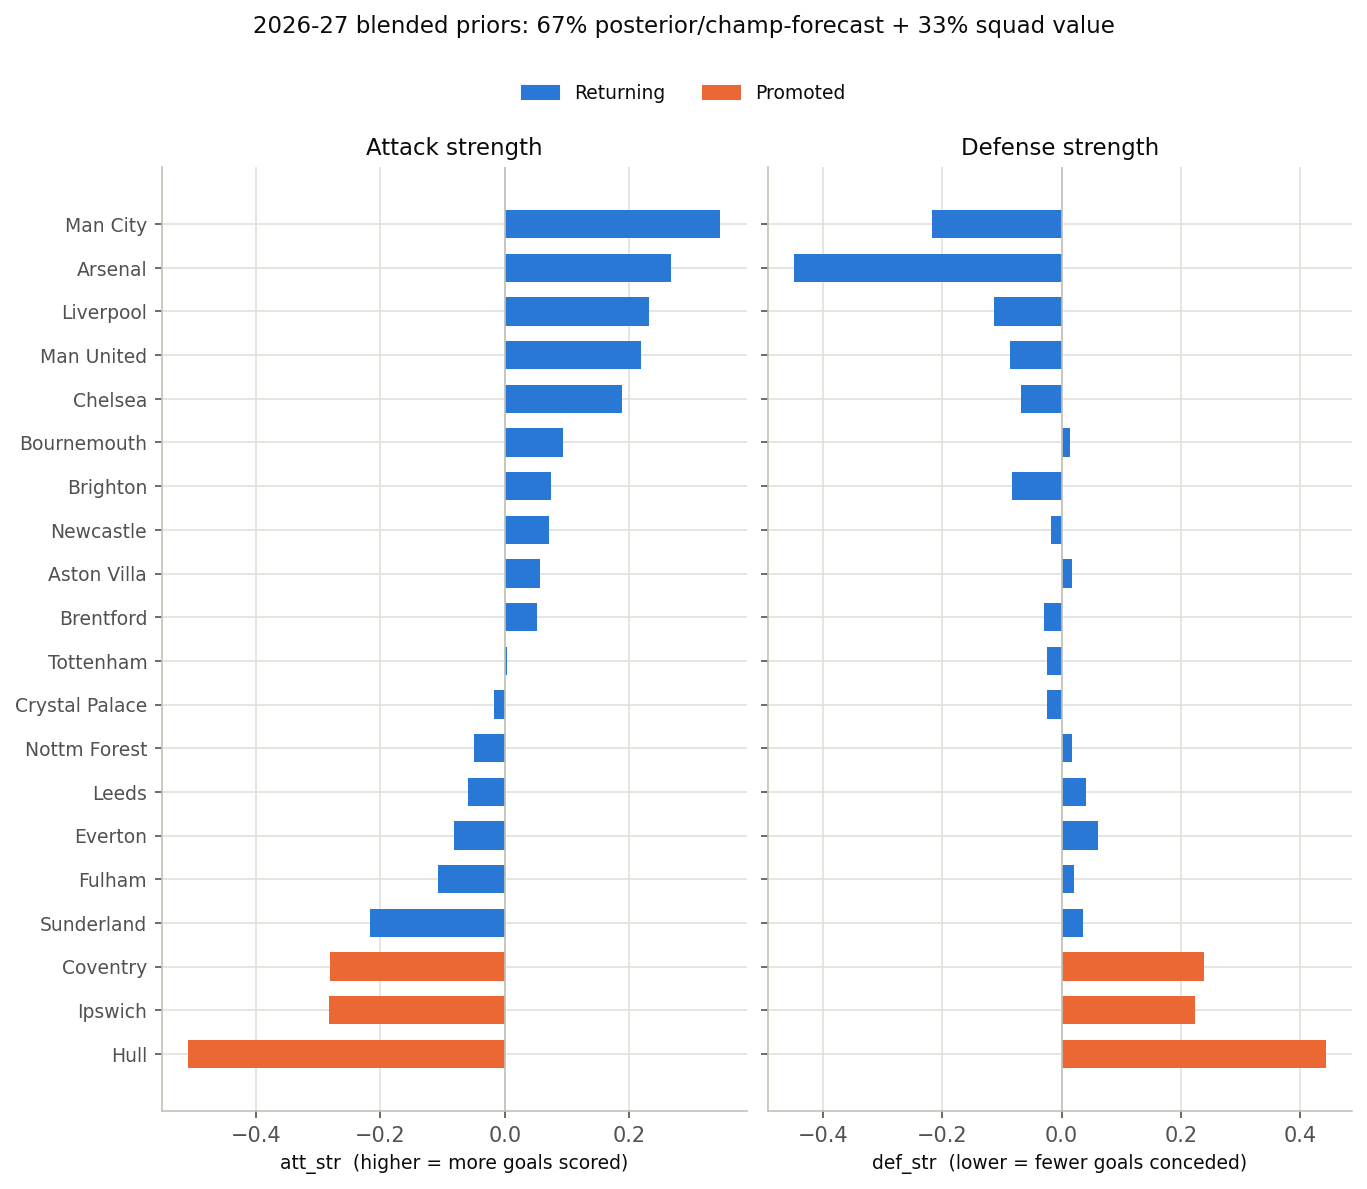

In [9]:
team_order = sorted(att_final, key=lambda t: att_final[t])  # bottom-to-top for barh
colors = [C_GOALS if t in PROMOTED else C_XG for t in team_order]

fig, axes = plt.subplots(1, 2, figsize=(9, 7), sharey=True, constrained_layout=True)

axes[0].barh(team_order, [att_final[t] for t in team_order], color=colors, height=0.65)
axes[0].set_title('Attack strength', fontsize=11, color=C_INK)
axes[0].axvline(0, color=C_AXIS, linewidth=0.8)
axes[0].set_xlabel('att_str  (higher = more goals scored)', fontsize=9)

axes[1].barh(team_order, [def_final[t] for t in team_order], color=colors, height=0.65)
axes[1].set_title('Defense strength', fontsize=11, color=C_INK)
axes[1].axvline(0, color=C_AXIS, linewidth=0.8)
axes[1].set_xlabel('def_str  (lower = fewer goals conceded)', fontsize=9)
for ax in axes:
    ax.tick_params(axis='y', labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=C_XG, label='Returning'), Patch(color=C_GOALS, label='Promoted')],
           loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=2, frameon=False, fontsize=9)
fig.suptitle('2026-27 blended priors: 67% posterior/champ-forecast + 33% squad value', fontsize=11, color=C_INK, y=1.11)

OUT_DIR = PRIORS_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)
plt.savefig(OUT_DIR / '2026_27_priors.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Write `manual_priors_2026_27.py`

Same format as the existing `manual_priors.py` (raw, pre-normalisation mu/sigma
pairs, re-normalised at import time) so it drops straight in as
`manual_att_priors=MANUAL_ATT_PRIORS, manual_def_priors=MANUAL_DEF_PRIORS`.

In [10]:
def _fmt_dict(raw: dict, sigma_map: dict) -> str:
    lines = []
    for t in RETURNING:
        lines.append(f"    {t!r:>18}: ({raw[t]:.3f}, {sigma_map[t]}),")
    lines.append("    # Promoted sides — wider prior")
    for t in PROMOTED:
        lines.append(f"    {t!r:>18}: ({raw[t]:.3f}, {sigma_map[t]}),")
    return "\n".join(lines)

# ── Sigma: hand-controlled, not auto-derived here ─────────────────────────────
# SIGMA_RETURNING/SIGMA_PROMOTED above are still useful empirical reference points (season-
# to-season strength volatility), but this notebook regenerates mu only -- sigma for any team
# already in the existing manual_priors_2026_27.py is preserved verbatim (e.g. the hand-set
# 0.3 established / 0.4 Europe-status-flipping / 0.5 promoted tiers), letting sigma_ramp_scale
# ramp up to whatever season-target sigma is currently in the file rather than this notebook's
# own preseason-tightened estimate. Only a team with no existing entry (e.g. a newly promoted
# side the very first time this file is generated for a season) falls back to the computed
# SIGMA_RETURNING/SIGMA_PROMOTED as a starting point to hand-tune from.
def _load_existing_sigma(path):
    if not path.exists():
        return {}
    import importlib.util
    spec = importlib.util.spec_from_file_location("_existing_manual_priors", path)
    mod = importlib.util.module_from_spec(spec)
    try:
        spec.loader.exec_module(mod)
    except Exception as e:
        print(f"WARNING: could not import existing {path} to preserve its sigmas ({e}); "
              f"falling back to computed SIGMA_RETURNING/SIGMA_PROMOTED for every team")
        return {}
    # _RAW_ATT/_RAW_DEF are pre-normalisation but sigma is untouched by normalisation
    return {t: sigma for t, (_, sigma) in mod._RAW_ATT.items()}

_existing_sigma = _load_existing_sigma(OUT_PRIORS_PY)
sigma_map = {
    t: _existing_sigma.get(t, SIGMA_PROMOTED if t in PROMOTED else SIGMA_RETURNING)
    for t in raw_att
}
_new_teams = [t for t in raw_att if t not in _existing_sigma]
if _new_teams:
    print(f"No existing sigma found (new team or first run) for: {_new_teams} "
          f"-> seeded from computed SIGMA_RETURNING/SIGMA_PROMOTED, hand-tune as needed")
else:
    print("Sigma preserved from existing manual_priors_2026_27.py for all 20 teams; "
          "only mu was regenerated.")

for _name, _val in [('SIGMA_RETURNING', SIGMA_RETURNING), ('SIGMA_PROMOTED', SIGMA_PROMOTED),
                     ('baseline', baseline), ('home_adv', home_adv)]:
    assert np.isfinite(_val), f"{_name} is not finite ({_val}) -- check TARGET_SEASON exclusions above before writing the file"

# Jensen-correction offset for baseline_mu, computed from *this* season's actual att/def
# spread (not hardcoded) -- see manual_priors_2026_27's own docstring for the derivation.
# exp() is convex, so averaging home_lam/away_lam over real (unequal) teams pushes the
# league-average predicted goal rate above the neutral-team rate baseline_mu is meant to
# represent; this subtracts exactly that expected inflation back out.
_att_mu_arr = np.array([raw_att[t] for t in raw_att]) - np.mean(list(raw_att.values()))
_def_mu_arr = np.array([raw_def[t] for t in raw_def]) - np.mean(list(raw_def.values()))
_jensen_correction_value = float(np.log(np.exp(_att_mu_arr).mean()) + np.log(np.exp(_def_mu_arr).mean()))
print(f"Jensen correction: {_jensen_correction_value:.4f}  "
      f"(baseline exp({baseline:.4f}) -> corrected exp({baseline - _jensen_correction_value:.4f}))")

FILE_TEMPLATE = f'''"""
manual_priors_2026_27.py — Hand-derived Bayesian priors for the Premier League model.

Generated by priors/2026_27_priors.ipynb from three blended sources:
  1. 2025-26 season posterior (att_str/def_str) for the 17 teams staying up.
  2. This season's Transfermarkt squad value regressed against non-penalty PL
     goals-for/against rate ({len(value_panel)} historical team-seasons, R²={value_gf_model.rsquared:.2f} attack /
     {value_ga_model.rsquared:.2f} defense), for all 20 teams -- weight {W_VALUE:.0%}.
  3. Championship-form PL forecast (champ_analysis.ipynb's promotion-effect
     model) for Hull, Coventry and Ipswich, in place of a posterior they don't have.

Sources 1/3 get weight {W_PRIMARY:.0%}, source 2 gets {W_VALUE:.0%}. Sigma is hand-set, not
auto-derived by this notebook -- regenerating this file only touches the mu values, sigma is
preserved from whatever's already here (see the file-writer cell in priors/2026_27_priors.ipynb
for the fallback used when a team has no existing entry yet). Relegated (real, penalty-inclusive
2025-26 table): {", ".join(sorted(RELEGATED))}.

Values are the raw (pre-normalisation) mu estimates. The model normalises them
at runtime by subtracting the mean across all teams, ensuring the priors sum to
zero (identifiability constraint).

Usage
-----
    # Mid-season (recommended): sigma ramps from ~half the values below at
    # GW1 up to the full values by GW10 -- see scaled_priors().
    from manual_priors_2026_27 import scaled_priors
    att_priors, def_priors = scaled_priors(games_played)
    _, trace = build_and_sample_model(
        df, n_teams, team_mapping=team_mapping,
        manual_att_priors=att_priors,
        manual_def_priors=def_priors,
    )

    # Season-target sigma directly, no ramp (e.g. preseason projections):
    from manual_priors_2026_27 import MANUAL_ATT_PRIORS, MANUAL_DEF_PRIORS
"""

import numpy as np

# ── Raw priors (pre-normalisation) ───────────────────────────────────────────

_RAW_ATT = {{
{_fmt_dict(raw_att, sigma_map)}
}}

_RAW_DEF = {{
{_fmt_dict(raw_def, sigma_map)}
}}


def _normalise(raw):
    """Subtract mean of mus so priors sum to zero (identifiability)."""
    teams = list(raw.keys())
    mus   = np.array([raw[t][0] for t in teams])
    mus  -= mus.mean()
    sigs  = np.array([raw[t][1] for t in teams])
    return {{t: (float(mus[i]), float(sigs[i])) for i, t in enumerate(teams)}}


MANUAL_ATT_PRIORS = _normalise(_RAW_ATT)
MANUAL_DEF_PRIORS = _normalise(_RAW_DEF)


# ── Early-season sigma ramp ───────────────────────────────────────────────────
# The sigmas above are a season-long target, calibrated against how much a team's strength
# genuinely varies season-to-season. Applied unchanged from GW1, they're too loose relative
# to how little real match data exists yet -- one extreme early scoreline swings a rating
# almost as much as it would mid-season. Empirically swept against 2025-26's actual final
# posterior: the RMSE-optimal sigma rises smoothly from ~half the season target at GW1 to
# the full target by GW10, so ramp sigma over that window rather than applying the season
# value from kickoff.
def sigma_ramp_scale(games_played: int, ramp_games: int = 10, start_fraction: float = 0.4) -> float:
    """
    Fraction of season-target sigma to use, given games played so far.

    Ramps linearly from `start_fraction` (of the season-target sigma) at zero
    games played, up to 1.0 (full season-target sigma) by `ramp_games` games
    played, then stays at 1.0 for the rest of the season.
    """
    if ramp_games <= 0:
        return 1.0
    progress = min(max(games_played, 0), ramp_games) / ramp_games
    return start_fraction + (1.0 - start_fraction) * progress


def scaled_priors(games_played: int, ramp_games: int = 10, start_fraction: float = 0.4):
    """
    Return (att_priors, def_priors) with sigma scaled per the early-season
    ramp -- mu is untouched. Use this instead of MANUAL_ATT_PRIORS /
    MANUAL_DEF_PRIORS directly when fitting mid-season, so early gameweeks
    aren't overreacting to a handful of results.
    """
    scale = sigma_ramp_scale(games_played, ramp_games, start_fraction)
    att = {{t: (mu, sigma * scale) for t, (mu, sigma) in MANUAL_ATT_PRIORS.items()}}
    defn = {{t: (mu, sigma * scale) for t, (mu, sigma) in MANUAL_DEF_PRIORS.items()}}
    return att, defn


# ── Global (home_adv/baseline) priors and their early-season ramp ────────────
# Recency-weighted (0.6**seasons_ago) empirical estimate from np_matches over the last 5
# *completed* seasons (see this notebook's section 1 -- TARGET_SEASON is deliberately
# excluded from that computation: it's what's being forecast, not a completed season to
# learn the league constant from).
HOME_ADV_PRIOR_MU = {home_adv:.4f}
HOME_ADV_PRIOR_SIGMA = 0.1
BASELINE_PRIOR_MU = {baseline:.4f}
BASELINE_PRIOR_SIGMA = 0.1

# ── Jensen correction ─────────────────────────────────────────────────────────
# BASELINE_PRIOR_MU above is calibrated to the *neutral* team (att_str=def_str=0) rate. But
# home_lam/away_lam use exp(baseline + ... + att_str[i] + def_str[j]), and exp() is convex --
# so averaging over real, unequal teams (this season's own MANUAL_ATT_PRIORS/MANUAL_DEF_PRIORS
# spread) pushes the *league-average* predicted goal rate above the neutral-team rate
# baseline_mu was meant to represent. Computed fresh from whichever priors are currently
# above, so it stays correct across regenerations even if next season's spread differs:
# E[exp(att_mu)]={np.exp(_att_mu_arr).mean():.4f}, E[exp(def_mu)]={np.exp(_def_mu_arr).mean():.4f} -> correction={_jensen_correction_value:.4f} log-units.
def _jensen_correction():
    att_mu = np.array([mu for mu, _ in MANUAL_ATT_PRIORS.values()])
    def_mu = np.array([mu for mu, _ in MANUAL_DEF_PRIORS.values()])
    return np.log(np.exp(att_mu).mean()) + np.log(np.exp(def_mu).mean())


BASELINE_PRIOR_MU_CORRECTED = BASELINE_PRIOR_MU - _jensen_correction()


def scaled_global_priors(games_played: int, ramp_games: int = 10, start_fraction: float = 0.4):
    """(home_adv_prior, baseline_prior) as (mu, sigma) tuples for build_and_sample_model,
    sigma-ramped the same way and over the same window as scaled_priors(). baseline_prior's
    mu is the Jensen-corrected value (see above), not the raw neutral-team BASELINE_PRIOR_MU."""
    scale = sigma_ramp_scale(games_played, ramp_games, start_fraction)
    home_adv_prior = (HOME_ADV_PRIOR_MU, HOME_ADV_PRIOR_SIGMA * scale)
    baseline_prior = (BASELINE_PRIOR_MU_CORRECTED, BASELINE_PRIOR_SIGMA * scale)
    return home_adv_prior, baseline_prior
'''

OUT_PRIORS_PY.write_text(FILE_TEMPLATE)
print(f"wrote {OUT_PRIORS_PY}")

# round-trip check: does re-importing and re-normalising reproduce att_final/def_final above?
import importlib.util
spec = importlib.util.spec_from_file_location("manual_priors_2026_27", OUT_PRIORS_PY)
_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_mod)
max_att_diff = max(abs(_mod.MANUAL_ATT_PRIORS[t][0] - att_final[t]) for t in att_final)
max_def_diff = max(abs(_mod.MANUAL_DEF_PRIORS[t][0] - def_final[t]) for t in def_final)
print(f"round-trip max abs diff: att={max_att_diff:.6f}  def={max_def_diff:.6f}")

Sigma preserved from existing manual_priors_2026_27.py for all 20 teams; only mu was regenerated.
Jensen correction: 0.0352  (baseline exp(0.2077) -> corrected exp(0.1725))
wrote /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league/manual_priors_2026_27.py
round-trip max abs diff: att=0.000488  def=0.000445
